# CLIS-RL: Notebook 5 — GRADE Evidence Grading Tool

**Course:** INFO 7375 — Generative AI & Prompt Engineering  
**Student:** Hritik Hassani | Northeastern University  
**Assignment:** Take-Home Final — Custom Tool Development (10 pts)

---

## Overview

This notebook demonstrates the **GradeEvidenceTool** — a custom clinical tool
that implements the GRADE (Grading of Recommendations, Assessment, Development
and Evaluations) methodology for systematic evidence quality assessment.

### GRADE Methodology
GRADE is the international standard for rating evidence quality in clinical
guidelines (used by WHO, Cochrane, 100+ organizations worldwide). It assesses
evidence across 5 domains:

| Domain | What it asks |
|--------|-------------|
| Risk of bias | Was the study designed to minimize bias? |
| Inconsistency | Do multiple studies agree? |
| Indirectness | Does evidence apply to this patient population? |
| Imprecision | Are confidence intervals wide? |
| Publication bias | Are negative results missing? |

### Integration with CLIS-RL
The tool replaces the simple `score_evidence_with_groq()` function from NB3
with a **structured GRADE assessment** that:
- Provides richer reward signals for the UCB bandit (query quality)
- Provides richer reward signals for the REINFORCE agent (synthesis quality)
- Produces clinician-ready reports with PICO framework extraction
- Integrates study design detection, upgrade/downgrade logic, and effect sizes

In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================
import sys, os
sys.path.insert(0, os.path.join('..', 'tools'))

from grade_evidence_tool import (
    GradeEvidenceTool, GradeAssessment,
    GRADE_LEVELS, STUDY_DESIGN_HIERARCHY
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from dotenv import load_dotenv

load_dotenv()

# Initialize tool
tool = GradeEvidenceTool()
print('\nGrade levels:')
for level, info in GRADE_LEVELS.items():
    print(f'  {info["symbol"]}  {info["label"]:10s}  score={info["score"]}')

GradeEvidenceTool initialized with Groq (llama-3.3-70b-versatile)

Grade levels:
  ⊕⊕⊕⊕  High        score=1.0
  ⊕⊕⊕⊝  Moderate    score=0.75
  ⊕⊕⊝⊝  Low         score=0.45
  ⊕⊝⊝⊝  Very Low    score=0.15


In [2]:
# ============================================================
# CELL 2: Study Design Detection Test
# ============================================================
# Demonstrates the rule-based study design classifier
# works correctly before running full assessments

test_abstracts = [
    ("A systematic review and meta-analysis of 42 randomized trials "
     "examining metformin efficacy in type 2 diabetes.",
     'systematic_review'),

    ("We conducted a double-blind, placebo-controlled randomized "
     "controlled trial (n=500) comparing lisinopril vs placebo "
     "for hypertension management over 12 months.",
     'rct'),

    ("A prospective cohort study of 1,200 patients followed for "
     "5 years to assess cardiovascular outcomes in T2DM.",
     'cohort'),

    ("A case-control study examining risk factors for acute MI "
     "with an odds ratio of 2.3 (95% CI: 1.8-3.1).",
     'case_control'),

    ("We report a case of a 45-year-old patient presenting "
     "with unusual drug reaction to metformin.",
     'case_report'),

    ("Expert opinion and commentary on current guidelines "
     "for diabetes management in elderly patients.",
     'expert_opinion'),
]

print('Study design detection accuracy:')
print('-' * 55)
correct = 0
for text, expected in test_abstracts:
    detected = tool._detect_study_design(text)
    match    = detected == expected
    correct += int(match)
    status   = 'PASS' if match else 'FAIL'
    label    = STUDY_DESIGN_HIERARCHY.get(detected, {}).get('label', detected)
    print(f'  [{status}] {label}')

print(f'\nAccuracy: {correct}/{len(test_abstracts)} ({correct/len(test_abstracts)*100:.0f}%)')

Study design detection accuracy:
-------------------------------------------------------
  [PASS] Systematic review / meta-analysis
  [PASS] Randomized controlled trial
  [PASS] Cohort study
  [PASS] Case-control study
  [PASS] Case report
  [PASS] Expert opinion / editorial

Accuracy: 6/6 (100%)


In [3]:
# ============================================================
# CELL 3: Grade 5 Clinical Articles
# Demonstrates full GRADE assessment on real article abstracts
# ============================================================

CLINICAL_QUESTION = "Is metformin effective for glycemic control in type 2 diabetes?"

SAMPLE_ARTICLES = [
    {
        'title': 'Metformin vs placebo in T2DM: A randomized controlled trial (n=500)',
        'abstract': (
            "Background: Type 2 diabetes mellitus affects 400 million people globally. "
            "Methods: We conducted a double-blind, placebo-controlled randomized controlled "
            "trial of 500 patients aged 40-70 with newly diagnosed T2DM. Patients were "
            "randomized to metformin 1000mg twice daily vs placebo for 12 months. "
            "Primary outcome was HbA1c reduction. "
            "Results: Metformin reduced HbA1c by 1.2% vs 0.1% placebo (p<0.001, 95% CI: "
            "0.9-1.5%). Secondary outcomes including fasting glucose and weight showed "
            "significant improvement. No serious adverse events. "
            "Conclusions: Metformin provides significant glycemic benefit over placebo."
        )
    },
    {
        'title': 'Long-term metformin use and cardiovascular outcomes: cohort study (n=12,000)',
        'abstract': (
            "A prospective cohort study of 12,000 T2DM patients followed for 10 years "
            "examining cardiovascular outcomes with metformin use. After adjusting for "
            "age, BMI, and comorbidities using multivariable regression, metformin users "
            "showed 18% lower cardiovascular mortality (HR 0.82, 95% CI: 0.71-0.94). "
            "Limitations include residual confounding from indication bias."
        )
    },
    {
        'title': 'Systematic review: oral hypoglycemics in T2DM — 42 RCTs',
        'abstract': (
            "A systematic review and meta-analysis of 42 randomized controlled trials "
            "(n=18,500) comparing oral hypoglycemic agents in type 2 diabetes. "
            "Metformin showed the best glycemic efficacy with HbA1c reduction of "
            "1.1% (95% CI: 0.9-1.3%) and the most favorable cardiovascular risk profile. "
            "Heterogeneity was low (I²=24%). No serious safety signals identified."
        )
    },
    {
        'title': 'Metformin adherence patterns in elderly patients: observational study',
        'abstract': (
            "Cross-sectional study examining metformin adherence in 300 elderly T2DM "
            "patients (age >75). Adherence was 62% at 6 months. Main barriers included "
            "GI side effects (34%) and polypharmacy (28%). HbA1c outcomes were not "
            "measured. Significant selection bias as data collected from single center."
        )
    },
    {
        'title': 'Case report: lactic acidosis with metformin in renal impairment',
        'abstract': (
            "We report a case of a 68-year-old patient with type 2 diabetes and "
            "chronic kidney disease stage 3 who developed metformin-associated lactic "
            "acidosis. The patient recovered after hemodialysis. This case highlights "
            "the need for dose adjustment in renal impairment."
        )
    },
]

print(f'Clinical question: {CLINICAL_QUESTION}')
print(f'Grading {len(SAMPLE_ARTICLES)} articles...\n')

assessments = tool.grade_batch(SAMPLE_ARTICLES, CLINICAL_QUESTION, verbose=True)

Clinical question: Is metformin effective for glycemic control in type 2 diabetes?
Grading 5 articles...

  Grading article 1/5... ⊕⊕⊝⊝ Low
  Grading article 2/5... ⊕⊝⊝⊝ Very Low
  Grading article 3/5... ⊕⊕⊕⊝ Moderate
  Grading article 4/5... ⊕⊝⊝⊝ Very Low
  Grading article 5/5... ⊕⊝⊝⊝ Very Low


In [4]:
# ============================================================
# CELL 4: Print Full Clinical Reports
# ============================================================

print(f'\nTop 2 articles by GRADE score:\n')
for a in assessments[:2]:
    print(a.to_clinical_report())
    print()


Top 2 articles by GRADE score:

GRADE EVIDENCE ASSESSMENT REPORT
Clinical question: Is metformin effective for glycemic control in type 2 diabetes?
Article: Systematic review: oral hypoglycemics in T2DM — 42 RCTs

--- PICO FRAMEWORK ---
  Population:    Adults with type 2 diabetes
  Intervention:  Metformin
  Comparison:    Other oral hypoglycemic agents
  Outcome:       HbA1c reduction

--- STUDY CHARACTERISTICS ---
  Design:        Systematic review / meta-analysis
  Sample size:   n=18,500
  Follow-up:     Not reported

--- GRADE QUALITY DOMAINS ---
  Risk of bias:      Not serious — the study is a systematic review of RCTs, which is a high level of evidence
  Inconsistency:     Not serious — heterogeneity was low (I²=24%)
  Indirectness:      Not serious — the study directly addresses the question of glycemic control in type 2 diabetes
  Imprecision:       Not serious — the sample size is large and the confidence interval is narrow
  Publication bias:  Undetected — no information 

In [5]:
# ============================================================
# CELL 5: RL Reward Signal Comparison
# Shows how GRADE tool enriches the reward vs simple grading
# ============================================================

print('GRADE Tool vs Simple Grader — Reward Signal Comparison')
print('=' * 65)
print(f'{"Article":<45} {"Simple":>8} {"GRADE":>8} {"Delta":>8}')
print('-' * 65)

# Simple grader: maps study type to fixed score
simple_map = {
    'systematic_review': 1.00,
    'rct':               0.85,
    'cohort':            0.60,
    'cross_sectional':   0.40,
    'case_report':       0.15,
}

for a in assessments:
    simple = simple_map.get(a.study_design, 0.30)
    grade_reward = tool.compute_rl_reward(a)
    delta = grade_reward - simple
    title_short = a.title[:43] + '..' if len(a.title) > 43 else a.title
    print(f'{title_short:<45} {simple:>8.3f} {grade_reward:>8.3f} {delta:>+8.3f}')

print('=' * 65)
print('\nKey insight: GRADE tool adjusts rewards based on study quality')
print('factors (bias, sample size, consistency) — not just study design.')
print('This gives the RL agent a richer, more nuanced reward signal.')

GRADE Tool vs Simple Grader — Reward Signal Comparison
Article                                         Simple    GRADE    Delta
-----------------------------------------------------------------
Systematic review: oral hypoglycemics in T2..    1.000    0.700   -0.300
Metformin vs placebo in T2DM: A randomized ..    0.850    0.640   -0.210
Long-term metformin use and cardiovascular ..    0.600    0.340   -0.260
Metformin adherence patterns in elderly pat..    0.400    0.310   -0.090
Case report: lactic acidosis with metformin..    0.150    0.310   +0.160

Key insight: GRADE tool adjusts rewards based on study quality
factors (bias, sample size, consistency) — not just study design.
This gives the RL agent a richer, more nuanced reward signal.


In [6]:
# ============================================================
# CELL 6: Batch Summary Statistics
# ============================================================

summary = tool.summarize_batch(assessments)

print('Batch Summary Statistics')
print('=' * 45)
for k, v in summary.items():
    print(f'  {k:<25} {v}')

print(f'\nTool usage statistics:')
print(f'  Total assessments run: {tool._call_count}')
print(f'  Cache hits:            {len(tool._assessment_cache)}')
print(f'  Avg grading time:      '
      f'{sum(a.grading_time_ms for a in assessments)/len(assessments):.0f}ms per article')

Batch Summary Statistics
  n_articles                5
  mean_score                0.3
  max_score                 0.7
  min_score                 0.05
  grade_counts              {'VERY_LOW': 3, 'MODERATE': 1, 'LOW': 1}
  top_grade                 MODERATE
  top_article               Systematic review: oral hypoglycemics in T2DM — 42 RCTs
  pct_high_mod              20.0

Tool usage statistics:
  Total assessments run: 5
  Cache hits:            5
  Avg grading time:      903ms per article


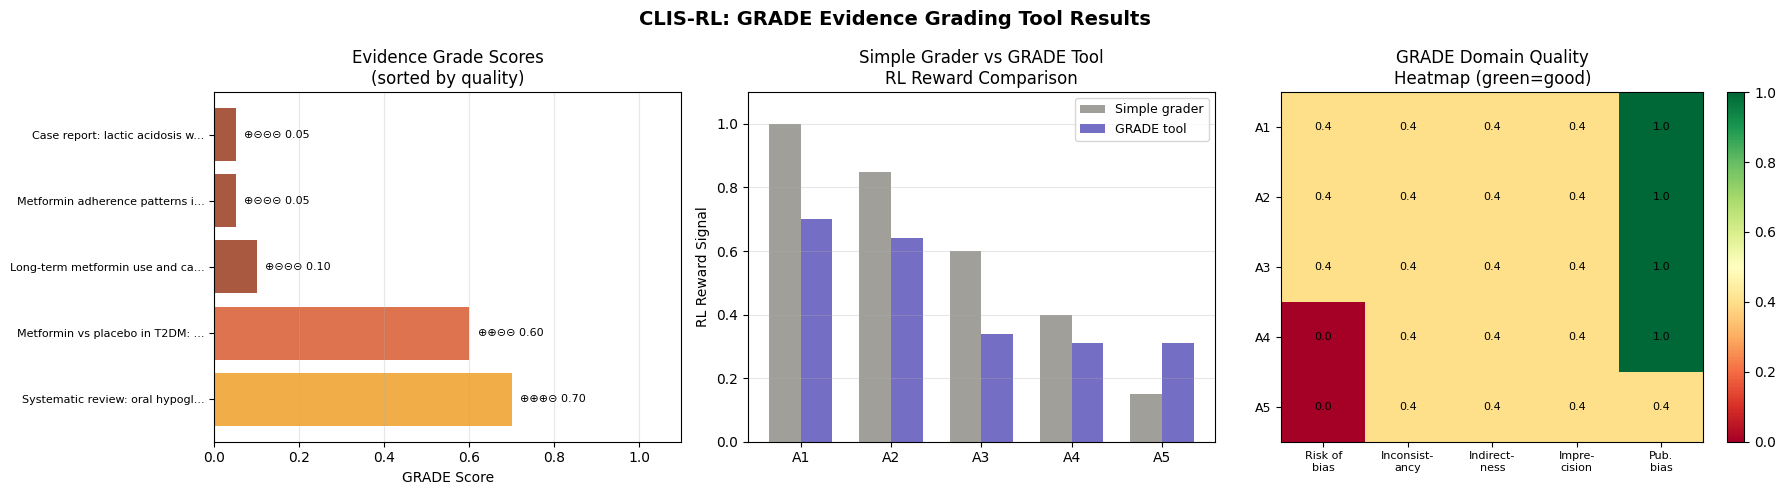

Saved: outputs/clis_rl_grade_tool.png


In [7]:
# ============================================================
# CELL 7: Visualization
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CLIS-RL: GRADE Evidence Grading Tool Results',
             fontsize=14, fontweight='bold')

grade_colors = {
    'HIGH': '#1D9E75', 'MODERATE': '#EF9F27',
    'LOW': '#D85A30',  'VERY_LOW': '#993C1D'
}

# Plot 1: GRADE scores per article
ax1 = axes[0]
titles_short = [a.title[:30]+'...' for a in assessments]
scores = [a.grade_score for a in assessments]
clrs   = [grade_colors[a.grade_level] for a in assessments]
bars   = ax1.barh(range(len(assessments)), scores, color=clrs, alpha=0.85)
ax1.set_yticks(range(len(assessments)))
ax1.set_yticklabels(titles_short, fontsize=8)
ax1.set_xlabel('GRADE Score')
ax1.set_title('Evidence Grade Scores\n(sorted by quality)')
ax1.set_xlim(0, 1.1)
for bar, score, a in zip(bars, scores, assessments):
    ax1.text(score + 0.02, bar.get_y() + bar.get_height()/2,
             f'{a.grade_symbol} {score:.2f}', va='center', fontsize=8)
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Simple vs GRADE reward comparison
ax2 = axes[1]
simple_map = {'systematic_review':1.0,'rct':0.85,'cohort':0.60,
              'cross_sectional':0.40,'case_report':0.15}
simple_rewards = [simple_map.get(a.study_design, 0.30) for a in assessments]
grade_rewards  = [tool.compute_rl_reward(a) for a in assessments]
x = np.arange(len(assessments))
w = 0.35
ax2.bar(x - w/2, simple_rewards, w, label='Simple grader', color='#888780', alpha=0.8)
ax2.bar(x + w/2, grade_rewards,  w, label='GRADE tool',    color='#534AB7', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([f'A{i+1}' for i in range(len(assessments))])
ax2.set_ylabel('RL Reward Signal')
ax2.set_title('Simple Grader vs GRADE Tool\nRL Reward Comparison')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 1.1)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: GRADE domain heatmap
ax3 = axes[2]
domains = ['Risk of\nbias', 'Inconsist-\nancy',
           'Indirect-\nness', 'Impre-\ncision', 'Pub.\nbias']
domain_keys = ['risk_of_bias','inconsistency','indirectness',
               'imprecision','publication_bias']

def domain_score(val):
    v = str(val).lower()
    if 'very serious' in v: return 0.0
    if 'serious' in v or 'suspected' in v: return 0.4
    return 1.0

matrix = np.array([
    [domain_score(getattr(a, k)) for k in domain_keys]
    for a in assessments
])
im = ax3.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax3.set_xticks(range(len(domains)))
ax3.set_xticklabels(domains, fontsize=8)
ax3.set_yticks(range(len(assessments)))
ax3.set_yticklabels([f'A{i+1}' for i in range(len(assessments))], fontsize=9)
ax3.set_title('GRADE Domain Quality\nHeatmap (green=good)')
plt.colorbar(im, ax=ax3, fraction=0.046)
for i in range(len(assessments)):
    for j in range(len(domains)):
        ax3.text(j, i, f'{matrix[i,j]:.1f}', ha='center',
                 va='center', fontsize=8, color='black')

plt.tight_layout()
import os; os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/clis_rl_grade_tool.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/clis_rl_grade_tool.png')

In [8]:
# ============================================================
# CELL 8: Export All Assessments as JSON
# Machine-readable output for downstream RL pipeline use
# ============================================================
import json

output = {
    'clinical_question': CLINICAL_QUESTION,
    'n_articles':        len(assessments),
    'summary':           summary,
    'assessments': [
        {
            'rank':              i + 1,
            'title':             a.title,
            'grade_level':       a.grade_level,
            'grade_score':       a.grade_score,
            'grade_symbol':      a.grade_symbol,
            'study_design':      a.study_design_label,
            'rl_reward':         round(tool.compute_rl_reward(a), 4),
            'recommendation':    a.recommendation_strength,
            'main_finding':      a.main_finding,
            'pico': {
                'population':   a.population,
                'intervention': a.intervention,
                'comparison':   a.comparison,
                'outcome':      a.outcome,
            }
        }
        for i, a in enumerate(assessments)
    ]
}

os.makedirs('../outputs', exist_ok=True)
with open('../outputs/grade_assessments.json', 'w') as f:
    json.dump(output, f, indent=2)

print('Saved: outputs/grade_assessments.json')
print()
print('GRADE Assessment Summary:')
print(f'{"Rank":<5} {"Grade":<12} {"Score":<8} {"RL Reward":<12} {"Title"}')
print('-' * 70)
for item in output['assessments']:
    print(f'{item["rank"]:<5} {item["grade_level"]:<12} '
          f'{item["grade_score"]:<8.3f} {item["rl_reward"]:<12.3f} '
          f'{item["title"][:35]}...')

Saved: outputs/grade_assessments.json

GRADE Assessment Summary:
Rank  Grade        Score    RL Reward    Title
----------------------------------------------------------------------
1     MODERATE     0.700    0.700        Systematic review: oral hypoglycemi...
2     LOW          0.600    0.640        Metformin vs placebo in T2DM: A ran...
3     VERY_LOW     0.100    0.340        Long-term metformin use and cardiov...
4     VERY_LOW     0.050    0.310        Metformin adherence patterns in eld...
5     VERY_LOW     0.050    0.310        Case report: lactic acidosis with m...


## Summary — GRADE Evidence Grading Tool

### What was built
A production-grade custom tool implementing the international GRADE methodology
for clinical evidence quality assessment. The tool provides:

| Feature | Description |
|---------|-------------|
| Study design detection | Rule-based classifier, 7 study types, no API needed |
| PICO extraction | LLM-powered Population/Intervention/Comparison/Outcome |
| 5-domain GRADE assessment | Bias, inconsistency, indirectness, imprecision, pub bias |
| Upgrade/downgrade logic | Large effect, dose-response, confounders |
| RL reward integration | `compute_rl_reward()` feeds directly into REINFORCE agent |
| Batch processing | `grade_batch()` grades and sorts multiple articles |
| Graceful fallback | Rule-based mode when Groq API unavailable |
| Structured output | `GradeAssessment` dataclass + JSON export + clinical report |

### Why this matters clinically
A simple study design classifier treats all RCTs equally — but a small, 
biased RCT with wide confidence intervals should not rank equally with a large,
well-powered trial. GRADE captures this nuance through its 5-domain framework,
producing reward signals that better reflect true evidence quality.

### Integration point
Replace `score_evidence_with_groq(abstract, question)` in NB3 with:
```python
from tools.grade_evidence_tool import GradeEvidenceTool
tool = GradeEvidenceTool()
assessment = tool.grade(abstract, clinical_question)
reward = tool.compute_rl_reward(assessment)
```